<a href="https://colab.research.google.com/github/nimshi82/Loan-Approval-AI-System/blob/main/Copy_of_finalmajor_project_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load dataset (replace file name if needed)
df = pd.read_csv("original_dataset.csv")

# View first 5 rows
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def loan_approval(row):
    if row['credit_score'] >= 650 and row['debt_to_income_ratio'] <= 0.4:
        return "Approved"
    elif row['credit_score'] < 600 or row['debt_to_income_ratio'] > 0.6:
        return "Rejected"
    else:
        if row['annual_income'] > row['loan_amount'] * 2:
            return "Approved"
        else:
            return "Rejected"

df['loan_status'] = df.apply(loan_approval, axis=1)

df[['credit_score','debt_to_income_ratio','annual_income','loan_amount','loan_status']].head()

,credit_score,debt_to_income_ratio,annual_income,loan_amount,loan_status
0,743,0.074,24240.19,17173.72,Approved
1,531,0.219,20172.98,22663.89,Rejected
2,779,0.234,26181.80,3631.36,Approved
3,809,0.264,11873.84,14939.23,Approved
4,663,0.260,25326.44,16551.71,Approved


In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
Approved,15794
Rejected,4206


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
marital_status,0
education_level,0
annual_income,0
monthly_income,0
employment_status,0
debt_to_income_ratio,0
credit_score,0
loan_amount,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# List of categorical columns
cat_cols = ['gender', 'marital_status', 'education_level', 'employment_status']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df['loan_status'] = df['loan_status'].map({'Approved':1, 'Rejected':0})

In [ ]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back,loan_status
0,59,1,1,2,24240.19,2020.02,0,0.074,743,17173.72,...,581.88,B5,7,40833.47,24302.07,1,0,1,1,1
1,72,0,1,0,20172.98,1681.08,0,0.219,531,22663.89,...,573.17,F1,5,27968.01,10803.01,1,0,3,1,0
2,49,0,2,1,26181.80,2181.82,0,0.234,779,3631.36,...,76.32,B4,2,15502.25,4505.44,0,0,0,1,1
3,35,0,2,1,11873.84,989.49,0,0.264,809,14939.23,...,468.07,A5,7,18157.79,5525.63,4,0,5,1,1
4,63,2,2,3,25326.44,2110.54,0,0.260,663,16551.71,...,395.50,D5,1,17467.56,3593.91,2,0,2,1,1


In [ ]:
X_train.shape, X_test.shape

((16000, 22), (4000, 22))

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.91225


In [ ]:
# random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.98975


In [ ]:
X = df.drop(['loan_status', 'credit_score', 'debt_to_income_ratio'], axis=1)
y = df['loan_status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("New Accuracy:", accuracy_score(y_test, rf_pred))

New Accuracy: 0.922


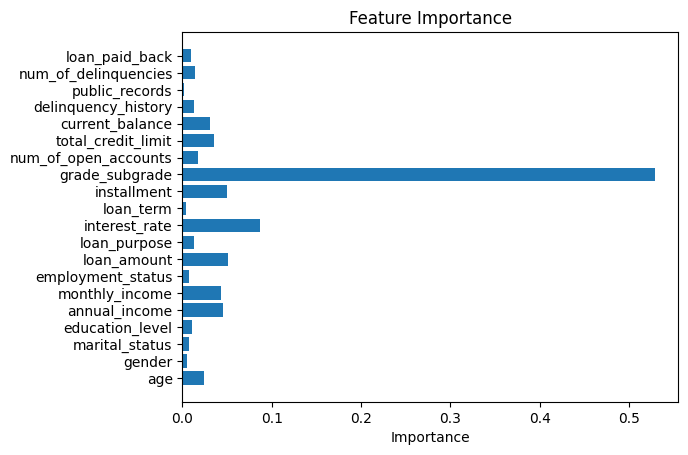

In [ ]:
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [ ]:
df_test = X_test.copy()
df_test['predicted'] = rf_model.predict(X_test)

df_test.groupby('gender')['predicted'].mean()

,predicted
gender,
0,0.784431
1,0.784241
2,0.733333
